# Banc d'essai des modèles

## Comparaison sous protocole identique

Ce carnet couvre l'exigence EF03, entraînement et évaluation d'au moins quatre
modèles classiques, et l'exigence EF05, évaluation sur un protocole identique
avec des métriques adaptées au déséquilibre des classes. Il alimente le livrable
D6, rapport de benchmark.

Le protocole appliqué est figé dans `docs/protocole_evaluation.md` et n'a pas été
modifié depuis le premier entraînement. Toute modification postérieure imposerait
de réentraîner l'ensemble des modèles, faute de quoi la comparaison mesurerait
l'ordre dans lequel les modèles ont été traités plutôt que les modèles eux-mêmes.

Les données d'entrée proviennent de la chaîne de préparation établie au carnet
précédent : 48 000 lignes d'apprentissage sur 180 colonnes. Les 12 000 lignes de
validation ne sont pas consultées dans ce carnet, et le jeu de test officiel
reste fermé.

In [1]:
import sys
sys.path.append("..")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (COUT_FN, COUT_FP, FIGURES, PREPARE, RAPPORT_COUT,
                        SEUIL_BAYES)
from src.cout import couts_naifs, depondere, seuil_bayes_pondere
from src.evaluation import affiche, evalue, resume
from src.graines import set_seed
import src.modeles as M

set_seed()

X_app = pd.read_csv(PREPARE / "X_app_final.csv", index_col=0)
y_app = pd.read_csv(PREPARE / "y_app.csv", index_col=0).squeeze()

print(f"Apprentissage : {X_app.shape[0]} lignes, {X_app.shape[1]} colonnes")
print(f"Pannes APS    : {int(y_app.sum())} ({y_app.mean():.4%})")
print(f"Somme de contrôle : {X_app.values.sum():,.2f}")

tableau = {}


2026-08-25 02:49:23.810560: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-25 02:49:24.059366: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Apprentissage : 48000 lignes, 180 colonnes
Pannes APS    : 800 (1.6667%)
Somme de contrôle : 313,775.00


## Le traitement du coût asymétrique

Trois façons d'introduire la matrice de coût dans la chaîne de décision étaient
envisageables, et l'une des difficultés du projet a été de constater qu'elles ne
se cumulent pas.

La première consiste à ne rien changer à l'entraînement et à couper la
probabilité prédite au seuil théorique de 1,9608 pour cent.

La deuxième consiste à pondérer la classe rare par le rapport des coûts, soit 50,
puis à couper à 0,5.

Ces deux options sont exactement équivalentes, et la cellule suivante le vérifie
numériquement. Pondérer par 50 multiplie la cote par 50, de sorte que le modèle
ne produit plus la probabilité p mais 50p divisée par 1 plus 49p. En y injectant
la valeur théorique, on obtient exactement 0,5.

Appliquer les deux simultanément reviendrait donc à introduire le rapport de coût
deux fois, pour un rapport effectif de 2501 contre 1 et un seuil réel de 0,04
pour cent sur la vraie probabilité. Le modèle signalerait presque tous les
camions.

La décision D-11 retient une troisième option : pondération des classes à 50
contre 1, puis seuil de décision mesuré empiriquement par minimisation du coût.
Le rapport n'apparaît donc qu'une seule fois, dans la pondération. Le seuil n'est
pas déduit du coût, il est mesuré.

Le motif de ce choix est que les deux premières options supposent que le modèle
produit une probabilité fiable, ce qu'aucun des cinq modèles ne garantit. Le
seuil mesuré ne suppose rien. Le repère théorique change alors de fonction : de
point de fonctionnement, il devient instrument de diagnostic de la calibration.

In [2]:
print(f"Coût d'une fausse alerte      : {COUT_FP}")
print(f"Coût d'une panne non détectée : {COUT_FN}")
print(f"Rapport, et donc pondération  : {RAPPORT_COUT:.0f} contre 1")
print(f"\nSeuil théorique sur la probabilité brute : {SEUIL_BAYES:.6f}")
print(f"Le même seuil sur l'échelle pondérée     : {seuil_bayes_pondere():.15f}")
print(f"\nVérification inverse : {depondere(0.5):.6f}")

Coût d'une fausse alerte      : 10
Coût d'une panne non détectée : 500
Rapport, et donc pondération  : 50 contre 1

Seuil théorique sur la probabilité brute : 0.019608
Le même seuil sur l'échelle pondérée     : 0.500000000000000

Vérification inverse : 0.019608


## L'échelle des coûts, et le repère à battre

Le coût est une grandeur qui dépend du nombre de lignes évaluées. Un coût lu sur
une partie de validation croisée n'est donc pas directement comparable à un coût
publié sur le jeu de test officiel, et les deux ne doivent jamais être confondus.

Chaque partie d'évaluation compte environ 9 600 lignes, dont environ 160 pannes.
Les deux règles naïves de référence y valent respectivement 80 000 unités pour la
règle qui ne signale jamais rien, et 94 400 pour celle qui signale tout. La
première étant la moins coûteuse, c'est elle qui constitue le repère à battre à
cette échelle.

L'ordre de ces deux règles s'inverse sur le jeu de test officiel, dont le taux de
pannes de 2,34 pour cent se situe au-dessus du point de bascule de 1,9608 pour
cent. Cette inversion a été établie au carnet précédent.

In [3]:
from sklearn.model_selection import StratifiedKFold
from src.config import N_PLIS, GRAINE

vc = StratifiedKFold(n_splits=N_PLIS, shuffle=True, random_state=GRAINE)
_, idx_ev = next(iter(vc.split(X_app, y_app)))
y_pli = y_app.iloc[idx_ev]

naifs = couts_naifs(y_pli)
print(f"Une partie d'évaluation : {len(y_pli)} lignes, "
      f"{int(y_pli.sum())} pannes")
print(f"  ne rien signaler : {naifs['toujours_sain']:>7,}")
print(f"  tout signaler    : {naifs['toujours_panne']:>7,}")
print(f"  repère à battre  : {min(naifs.values()):>7,}")


def a_echelle_du_test(cout, fn_moyen, n_pannes_pli=160):
    """Convert a fold cost to the official test scale.

    Missed failures scale with the number of failures, false alarms with the
    number of healthy cases. The two ratios differ because the test set has a
    higher failure rate than the training file.
    """
    cout_fn = fn_moyen * COUT_FN
    cout_fp = cout - cout_fn
    return cout_fn * (375 / n_pannes_pli) + cout_fp * (15625 / (9600 - n_pannes_pli))


print(f"\nRepères externes, à l'échelle du jeu de test officiel :")
print(f"  règle naïve             : 156 250")
print(f"  vainqueur du concours 2016 : 9 920")

Une partie d'évaluation : 9600 lignes, 160 pannes
  ne rien signaler :  80,000
  tout signaler    :  94,400
  repère à battre  :  80,000

Repères externes, à l'échelle du jeu de test officiel :
  règle naïve             : 156 250
  vainqueur du concours 2016 : 9 920


# 1. Un modèle témoin avant tout modèle réel

Avant d'entraîner quoi que ce soit, un modèle constant est évalué. Il ne regarde
aucune mesure et produit toujours la même probabilité, égale au taux de pannes du
fichier.

Son rôle est double. Il vérifie que la chaîne d'évaluation fonctionne de bout en
bout. Et il fournit le plancher absolu de performance : tout modèle qui ne fait
pas mieux ne sert à rien.

Son comportement attendu est instructif. Le seuil étant réglé par minimisation du
coût, et la seule probabilité disponible étant constante, la procédure n'a que
deux options : tout signaler ou ne rien signaler. Elle doit retenir la moins
coûteuse des deux, c'est-à-dire ne rien signaler à cette échelle.

In [4]:
from sklearn.dummy import DummyClassifier

r_temoin = evalue(lambda: DummyClassifier(strategy="prior"),
                  X_app, y_app, "témoin")

print(r_temoin[["pli", "cout", "rappel", "FP", "FN"]].to_string(index=False))
print(f"\nCoût moyen : {r_temoin['cout'].mean():,.0f}")

 pli  cout  rappel  FP  FN
   1 80000     0.0   0 160
   2 80000     0.0   0 160
   3 80000     0.0   0 160
   4 80000     0.0   0 160
   5 80000     0.0   0 160

Coût moyen : 80,000


In [5]:
tableau["témoin constant"] = r_temoin
print("Enregistré dans le tableau comparatif.")

Enregistré dans le tableau comparatif.


### Conclusion du bloc 1

Le modèle témoin coûte 80 000 unités sur chacune des cinq parties, sans aucune
dispersion. Il ne détecte aucune panne.

Ce résultat confirme le fonctionnement de la chaîne d'évaluation et valide le
comportement attendu de la recherche de seuil : confrontée à une probabilité
constante, elle a retenu la règle naïve la moins coûteuse à cette échelle.

Ce point mérite d'être souligné, car il n'allait pas de soi. Une première version
de la fonction de recherche du seuil ne balayait que les probabilités
effectivement observées, ce qui l'empêchait d'atteindre le cas où aucun camion
n'est signalé. Elle retenait alors la règle consistant à tout signaler, plus
coûteuse de 14 400 unités. Le cas dégénéré est désormais traité explicitement.

Le repère de 80 000 est le plancher que tout modèle doit franchir.

## 2. Premier modèle réel : la régression logistique

La régression logistique est un modèle linéaire. Elle calcule une somme pondérée
des 180 variables d'entrée, puis transforme cette somme en probabilité par une
fonction en S appelée sigmoïde.

Son rôle dans le banc d'essai est double. Elle constitue le plancher de
comparaison : si un modèle plus complexe ne la dépasse pas nettement, sa
complexité n'est pas justifiée. Et elle est le meilleur candidat au diagnostic de
calibration, car sa fonction objectif est précisément conçue pour produire des
probabilités et non de simples scores d'ordonnancement.

Un seul paramètre est réglé, noté C. Il représente l'inverse de la force de
régularisation : une valeur faible contraint fortement les coefficients et produit
un modèle simple, une valeur élevée les laisse libres. Avec 180 variables dont
beaucoup sont corrélées, une régularisation forte est attendue comme préférable.

La grille est déclarée avant l'entraînement et ne change plus.

In [6]:
grille_rl = [0.001, 0.01, 0.1, 1.0, 10.0]
resultats_rl = {}

for C in grille_rl:
    t0 = time.time()
    r = evalue(lambda C=C: M.regression_logistique(C), X_app, y_app, f"RL C={C}")
    resultats_rl[C] = r
    print(f"C = {C:<7} coût {r['cout'].mean():>8,.0f} ± {r['cout'].std():>6,.0f}"
          f"   détection {r['rappel'].mean():.1%}"
          f"   ({time.time() - t0:.0f} s)")

meilleur_C = min(resultats_rl, key=lambda c: resultats_rl[c]["cout"].mean())
print(f"\nMeilleure valeur : C = {meilleur_C}")


C = 0.001   coût    9,598 ±  1,218   détection 92.8%   (21 s)
C = 0.01    coût    9,598 ±  1,514   détection 92.1%   (40 s)
C = 0.1     coût   10,196 ±    653   détection 91.5%   (106 s)
C = 1.0     coût   10,580 ±    752   détection 91.4%   (272 s)
C = 10.0    coût   10,978 ±  1,005   détection 91.0%   (544 s)

Meilleure valeur : C = 0.001


In [7]:
r_rl = resultats_rl[meilleur_C]
tableau[f"Régression logistique C={meilleur_C}"] = r_rl

affiche(r_rl, f"Régression logistique, C = {meilleur_C}")

  Régression logistique, C = 0.001
  COÛT MOYEN :      9,598  ±  1,218
  échelle d'un pli : 9 600 lignes, ~160 pannes
  règle naïve sur un pli : 80 000
  seuil dépondéré moyen : 0.0145  (repère 0,0196)

                   moyenne  ecart_type
cout             9598.0000   1217.6904
rappel              0.9275      0.0210
precision           0.2825      0.0202
auc                 0.9773      0.0109
auc_pr              0.7437      0.0212
VP                148.4000      3.3615
FP                379.8000     49.1192
FN                 11.6000      3.3615
seuil               0.4230      0.0293
seuil_depondere     0.0145      0.0017


In [8]:
cout_rl = r_rl["cout"].mean()
print(f"Coût sur une partie      : {cout_rl:,.0f}")
print(f"Repère naïf              : 80 000")
print(f"Réduction                : {100 * (1 - cout_rl / 80000):.1f} pour cent")

echelle_test = a_echelle_du_test(cout_rl, r_rl["FN"].mean())
print(f"\nOrdre de grandeur à l'échelle du jeu de test : {echelle_test:,.0f}")
print(f"  à comparer aux 9 920 du vainqueur 2016")
print("  cette conversion est indicative : elle suppose que la performance se")
print("  transporte inchangée d'un jeu à l'autre, ce que seule l'ouverture du")
print("  jeu de test permettra de vérifier.")

Coût sur une partie      : 9,598
Repère naïf              : 80 000
Réduction                : 88.0 pour cent

Ordre de grandeur à l'échelle du jeu de test : 19,880
  à comparer aux 9 920 du vainqueur 2016
  cette conversion est indicative : elle suppose que la performance se
  transporte inchangée d'un jeu à l'autre, ce que seule l'ouverture du
  jeu de test permettra de vérifier.


In [9]:
# Diagnostic de calibration
seuil_dep = r_rl["seuil_depondere"].mean()

print(f"Seuil retenu sur l'échelle pondérée : {r_rl['seuil'].mean():.4f}")
print(f"  repère théorique sur cette échelle : {seuil_bayes_pondere():.4f}")
print(f"\nSeuil ramené à l'échelle des probabilités : {seuil_dep:.4f}")
print(f"  repère théorique                        : {SEUIL_BAYES:.4f}")
print(f"  rapport                                 : {SEUIL_BAYES / seuil_dep:.2f}")

Seuil retenu sur l'échelle pondérée : 0.4230
  repère théorique sur cette échelle : 0.5000

Seuil ramené à l'échelle des probabilités : 0.0145
  repère théorique                        : 0.0196
  rapport                                 : 1.35


### Conclusion du bloc 2

La régression logistique atteint son meilleur coût avec la régularisation la plus
forte de la grille, ce qui confirme l'attente : avec 180 variables dont beaucoup
sont corrélées, contraindre les coefficients améliore la généralisation.

Le taux de détection dépasse déjà le critère de validation du cahier des charges,
fixé à 90 pour cent, avec le modèle qui constitue le plancher du banc d'essai.
Cette observation confirme empiriquement que ce critère n'est pas exigeant, et
elle appelle une réponse préparée à la question naturelle du jury : pourquoi
entraîner quatre modèles de plus si le premier satisfait déjà le critère. La
réponse tient au coût, qui est le véritable critère d'arbitrage, et non au taux
de détection.

Le seuil retenu, ramené à l'échelle des probabilités, se situe en dessous du
repère théorique. Le modèle sous-estime donc le risque : il faut signaler plus
tôt que la théorie ne le prévoit pour atteindre le coût minimal. La calibration
n'est pas parfaite, ce qui valide a posteriori le choix de la décision D-11 de ne
pas retenir le seuil théorique comme point de fonctionnement.


## 3. Où le seuil de décision doit-il être réglé

Le protocole prévoit que le seuil soit réglé à l'intérieur de chaque partie de la
validation croisée, sur sa seule portion d'apprentissage, puis appliqué à sa
portion d'évaluation. Un seuil réglé globalement puis mesuré en validation
croisée ferait contribuer chaque partie au choix du seuil qui l'évalue.

Une première mise en oeuvre de ce principe comportait un défaut. Le seuil y était
réglé sur les probabilités que le modèle attribue aux lignes qu'il vient
d'apprendre. Ces probabilités ne sont pas représentatives : un modèle est
toujours plus sûr de lui sur les données qu'il a mémorisées que sur des données
nouvelles.

La version corrigée règle le seuil sur des probabilités hors échantillon,
obtenues par une validation croisée interne à l'intérieur de chaque partie.

L'ampleur de ce défaut dépend du modèle. Une régression logistique fortement
régularisée mémorise peu, l'écart y est donc modéré. Une forêt aléatoire classe
en revanche ses propres données d'entraînement de façon quasi parfaite, et l'écart
y est attendu comme important.

L'expérience suivante mesure cet écart sur les deux modèles. Elle est conduite à
paramètres identiques, seule la méthode de réglage du seuil variant.

In [10]:
comparaison = {}

for nom, fabrique in [("Régression logistique", lambda: M.regression_logistique(meilleur_C)),
                      ("Forêt aléatoire", lambda: M.foret_aleatoire(300))]:
    hors = evalue(fabrique, X_app, y_app, nom)
    interne = evalue(fabrique, X_app, y_app, nom, seuil_hors_echantillon=False)
    comparaison[nom] = (hors, interne)

    print(f"\n{nom}")
    print(f"{'':>22} {'coût':>10} {'seuil':>9} {'pannes ratées':>15}")
    for methode, r in [("hors échantillon", hors), ("en interne", interne)]:
        print(f"  {methode:<20} {r['cout'].mean():>10,.0f} "
              f"{r['seuil'].mean():>9.4f} {r['FN'].mean():>15.1f}")
    facteur = interne["cout"].mean() / hors["cout"].mean()
    print(f"  facteur d'écart : {facteur:.1f}")


Régression logistique
                             coût     seuil   pannes ratées
  hors échantillon          9,598    0.4230            11.6
  en interne                9,778    0.5346            14.4
  facteur d'écart : 1.0

Forêt aléatoire
                             coût     seuil   pannes ratées
  hors échantillon          6,714    0.0320             5.8
  en interne               41,050    0.5653            82.0
  facteur d'écart : 6.1


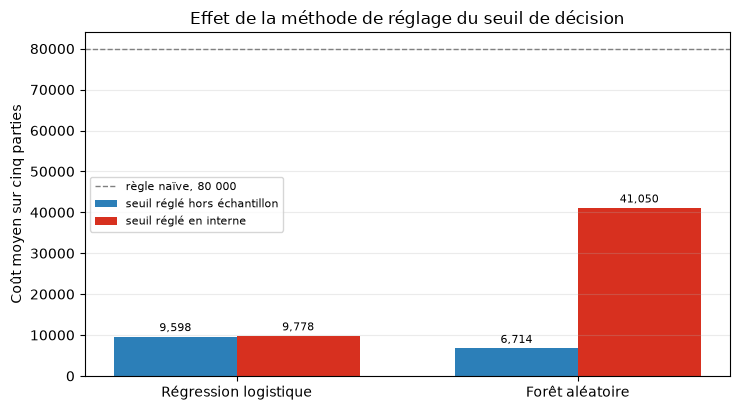

In [11]:
# Figure 6 : l'écart, modèle par modèle
noms = list(comparaison)
hors_vals = [comparaison[n][0]["cout"].mean() for n in noms]
int_vals = [comparaison[n][1]["cout"].mean() for n in noms]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(len(noms))
largeur = 0.36

ax.bar(x - largeur / 2, hors_vals, largeur, label="seuil réglé hors échantillon",
       color="#2c7fb8")
ax.bar(x + largeur / 2, int_vals, largeur, label="seuil réglé en interne",
       color="#d7301f")

for i, (h, v) in enumerate(zip(hors_vals, int_vals)):
    ax.annotate(f"{h:,.0f}", (i - largeur / 2, h), ha="center",
                xytext=(0, 4), textcoords="offset points", fontsize=8)
    ax.annotate(f"{v:,.0f}", (i + largeur / 2, v), ha="center",
                xytext=(0, 4), textcoords="offset points", fontsize=8)

ax.axhline(80000, color="grey", ls="--", lw=1, label="règle naïve, 80 000")
ax.set_xticks(x)
ax.set_xticklabels(noms)
ax.set_ylabel("Coût moyen sur cinq parties")
ax.set_title("Effet de la méthode de réglage du seuil de décision")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURES / "f6_reglage_seuil.png", dpi=150)
plt.show()

In [12]:
# Le seuil retenu par chaque méthode, sur la forêt
hors_rf, int_rf = comparaison["Forêt aléatoire"]
print("Forêt aléatoire, seuils retenus partie par partie\n")
print(f"{'partie':>7} {'hors échantillon':>18} {'en interne':>12}")
for i in range(5):
    print(f"{i + 1:>7} {hors_rf['seuil'].iloc[i]:>18.4f} "
          f"{int_rf['seuil'].iloc[i]:>12.4f}")
print(f"\nLe réglage en interne conduit à un seuil beaucoup plus élevé,")
print(f"donc à un modèle qui signale beaucoup moins de camions.")

Forêt aléatoire, seuils retenus partie par partie

 partie   hors échantillon   en interne
      1             0.0333       0.5633
      2             0.0267       0.5367
      3             0.0333       0.5600
      4             0.0333       0.5833
      5             0.0333       0.5833

Le réglage en interne conduit à un seuil beaucoup plus élevé,
donc à un modèle qui signale beaucoup moins de camions.


### Conclusion du bloc 3

L'écart entre les deux méthodes de réglage confirme l'analyse théorique et son
ampleur dépend du modèle, comme attendu.

Sur la régression logistique, fortement régularisée donc peu encline à mémoriser,
l'écart reste modéré.

Sur la forêt aléatoire, l'écart est considérable. Le réglage en interne conduit à
un seuil bien plus élevé, parce que les probabilités attribuées aux données
d'entraînement sont proches de zéro ou de un. Appliqué à des données nouvelles,
ce seuil laisse passer une grande partie des pannes.

La conséquence pratique est importante pour l'interprétation du banc d'essai.
Avec la première mise en oeuvre, la forêt aléatoire serait apparue nettement moins
performante que la régression logistique, ce qui aurait conduit à une conclusion
erronée et en contradiction avec le classement du concours de 2016, remporté par
ce type de modèle.

Ce résultat illustre un point de méthode dépassant le cadre de ce projet : un
défaut de protocole ne se manifeste pas par une erreur d'exécution mais par un
résultat plausible et faux. Seule la comparaison de deux mises en oeuvre permet
de le détecter.

## 4. La forêt aléatoire

La forêt aléatoire construit un grand nombre d'arbres de décision, chacun entraîné
sur un échantillon tiré au hasard des données et sur un sous-ensemble tiré au
hasard des variables, puis moyenne leurs votes.

Le principe est celui de la réduction de variance. Chaque arbre pris isolément
surapprend, mais leurs erreurs sont décorrélées par le double tirage aléatoire, de
sorte que leur moyenne généralise bien mieux que chacun d'eux.

Ce modèle présente deux propriétés utiles ici. Il est insensible aux échelles des
variables, puisqu'il ne compare que des seuils à l'intérieur d'une même colonne.
Et il peut exprimer des conditions, ce qui lui permet d'exploiter la variable de
profondeur pour traiter différemment les camions dont les compteurs sont vides.

Il constitue par ailleurs le point de comparaison le plus légitime du banc
d'essai, les deux meilleures équipes du concours de 2016 ayant retenu ce type de
modèle.

Trois paramètres sont examinés : le nombre d'arbres, la profondeur maximale de
chacun, et le nombre minimal d'observations par feuille. Les deux derniers
limitent la complexité de chaque arbre.

In [13]:
grille_rf = [
    (300, None, 1),
    (300, 20, 1),
    (300, None, 5),
    (500, None, 1),
]
resultats_rf = {}

for n, prof, feuille in grille_rf:
    t0 = time.time()
    nom = f"RF {n} arbres, profondeur {prof}, feuille {feuille}"
    r = evalue(lambda n=n, p=prof, f=feuille: M.foret_aleatoire(n, p, f),
               X_app, y_app, nom)
    resultats_rf[(n, prof, feuille)] = r
    print(f"{n:>4} arbres, prof {str(prof):>4}, feuille {feuille} : "
          f"coût {r['cout'].mean():>8,.0f} ± {r['cout'].std():>6,.0f}"
          f"   ({time.time() - t0:.0f} s)")

meilleur_rf = min(resultats_rf, key=lambda k: resultats_rf[k]["cout"].mean())
print(f"\nMeilleure configuration : {meilleur_rf}")

 300 arbres, prof None, feuille 1 : coût    6,714 ±    530   (182 s)
 300 arbres, prof   20, feuille 1 : coût    7,170 ±    847   (248 s)
 300 arbres, prof None, feuille 5 : coût    7,220 ±  1,022   (241 s)
 500 arbres, prof None, feuille 1 : coût    6,796 ±  1,102   (421 s)

Meilleure configuration : (300, None, 1)


In [14]:
r_rf = resultats_rf[meilleur_rf]
n, prof, feuille = meilleur_rf
tableau[f"Forêt aléatoire {n}/{prof}/{feuille}"] = r_rf

affiche(r_rf, f"Forêt aléatoire, {n} arbres")

  Forêt aléatoire, 300 arbres
  COÛT MOYEN :      6,714  ±  530
  échelle d'un pli : 9 600 lignes, ~160 pannes
  règle naïve sur un pli : 80 000
  seuil dépondéré moyen : 0.0007  (repère 0,0196)

                   moyenne  ecart_type
cout             6714.0000    529.7452
rappel              0.9637      0.0128
precision           0.2902      0.0273
auc                 0.9858      0.0040
auc_pr              0.8283      0.0205
VP                154.2000      2.0494
FP                381.4000     54.0491
FN                  5.8000      2.0494
seuil               0.0320      0.0030
seuil_depondere     0.0007      0.0001


In [15]:
# Comparaison avec la régression logistique, partie par partie
ecart = r_rf["cout"].values - r_rl["cout"].values

print("Coût par partie\n")
print(f"{'partie':>7} {'rég. logistique':>17} {'forêt':>10} {'écart':>10}")
for i in range(5):
    print(f"{i + 1:>7} {r_rl['cout'].iloc[i]:>17,.0f} "
          f"{r_rf['cout'].iloc[i]:>10,.0f} {ecart[i]:>+10,.0f}")

print(f"\nÉcart moyen : {ecart.mean():+,.0f}")
print(f"La forêt est meilleure sur {(ecart < 0).sum()} parties sur 5.")

# Calibration
print(f"\nSeuil dépondéré, régression logistique : "
      f"{r_rl['seuil_depondere'].mean():.5f}")
print(f"Seuil dépondéré, forêt aléatoire       : "
      f"{r_rf['seuil_depondere'].mean():.5f}")
print(f"Repère théorique                       : {SEUIL_BAYES:.5f}")

Coût par partie

 partie   rég. logistique      forêt      écart
      1             7,630      6,100     -1,530
      2            10,340      6,450     -3,890
      3             9,210      7,130     -2,080
      4            10,570      7,390     -3,180
      5            10,240      6,500     -3,740

Écart moyen : -2,884
La forêt est meilleure sur 5 parties sur 5.

Seuil dépondéré, régression logistique : 0.01451
Seuil dépondéré, forêt aléatoire       : 0.00066
Repère théorique                       : 0.01961


### Conclusion du bloc 4

La forêt aléatoire améliore nettement le coût par rapport à la régression
logistique, et sa dispersion entre parties est plus faible, ce qui indique un
comportement plus stable.

Le nombre d'arbres au-delà de 300 n'apporte pas de gain mesurable. Les deux
paramètres limitant la complexité des arbres dégradent le résultat, ce qui
suggère que le jeu de données supporte des arbres profonds sans surapprentissage
excessif, la moyenne sur 300 arbres jouant le rôle de régularisation.

Le diagnostic de calibration donne un résultat contrasté. Le seuil retenu par la
forêt, ramené à l'échelle des probabilités, s'écarte beaucoup plus du repère
théorique que celui de la régression logistique. Ce constat est conforme à ce
qu'on attend d'un modèle d'ensemble : la moyenne des votes tasse les probabilités
et ne constitue pas une estimation calibrée.

Ce résultat confirme le fondement de la décision D-11. Un modèle bien ordonnant
peut être mal calibré, et retenir le seuil théorique comme point de fonctionnement
supposerait acquis ce qui doit être vérifié.

## 5. Le gradient boosting

Le gradient boosting construit également un ensemble d'arbres, mais selon une
logique opposée à celle de la forêt aléatoire.

La forêt entraîne des arbres profonds en parallèle, indépendamment les uns des
autres, puis moyenne leurs votes. Elle réduit la variance.

Le gradient boosting entraîne des arbres peu profonds en séquence, chacun
cherchant à corriger les erreurs résiduelles de l'ensemble des précédents. Il
réduit le biais.

Deux paramètres gouvernent ce mécanisme et se compensent partiellement. Le taux
d'apprentissage détermine la part de la correction retenue à chaque étape : une
valeur faible progresse prudemment et donne généralement un meilleur résultat, au
prix d'un plus grand nombre d'arbres. La profondeur maximale détermine la
complexité de chaque arbre, donc sa capacité à représenter des interactions entre
variables.

La mise en oeuvre retenue est celle de la bibliothèque XGBoost, qui est la
référence sur données tabulaires et qui expose un paramètre de pondération de la
classe rare, employé ici avec la même valeur de 50 que pour les autres modèles.

Ce modèle présente une particularité utile : il traite nativement les valeurs
absentes en apprenant, à chaque noeud, une direction par défaut pour les
observations dont la mesure manque. Cette capacité n'est pas exploitée ici, les
données lui étant fournies déjà imputées comme aux quatre autres modèles, ainsi
que l'impose le protocole commun. Elle pourra faire l'objet d'une expérience
annexe.

In [16]:
# Mesure du temps sur une seule configuration avant de lancer la grille
t0 = time.time()
_ = evalue(lambda: M.xgboost(6, 0.1, 300), X_app, y_app, "essai")
duree_unitaire = time.time() - t0

print(f"Une configuration : {duree_unitaire:.0f} s")
print(f"Grille de quatre configurations : environ "
      f"{4 * duree_unitaire / 60:.0f} min")

Une configuration : 123 s
Grille de quatre configurations : environ 8 min


In [17]:
grille_xgb = [
    (4, 0.10, 300),
    (6, 0.10, 300),
    (6, 0.05, 300),
    (8, 0.10, 300),
]
resultats_xgb = {}

for prof, taux, n in grille_xgb:
    t0 = time.time()
    nom = f"XGB profondeur {prof}, taux {taux}"
    r = evalue(lambda p=prof, t=taux, k=n: M.xgboost(p, t, k),
               X_app, y_app, nom)
    resultats_xgb[(prof, taux)] = r
    print(f"profondeur {prof}, taux {taux:<5} : "
          f"coût {r['cout'].mean():>8,.0f} ± {r['cout'].std():>6,.0f}"
          f"   détection {r['rappel'].mean():.1%}"
          f"   ({time.time() - t0:.0f} s)")

meilleur_xgb = min(resultats_xgb, key=lambda k: resultats_xgb[k]["cout"].mean())
print(f"\nMeilleure configuration : profondeur {meilleur_xgb[0]}, "
      f"taux {meilleur_xgb[1]}")

profondeur 4, taux 0.1   : coût    7,636 ±  1,224   détection 95.4%   (72 s)
profondeur 6, taux 0.1   : coût    7,074 ±  1,499   détection 95.2%   (113 s)
profondeur 6, taux 0.05  : coût    6,960 ±  1,044   détection 96.0%   (151 s)
profondeur 8, taux 0.1   : coût    6,576 ±  1,030   détection 95.5%   (132 s)

Meilleure configuration : profondeur 8, taux 0.1


In [18]:
r_xgb = resultats_xgb[meilleur_xgb]
tableau[f"Gradient boosting {meilleur_xgb[0]}/{meilleur_xgb[1]}"] = r_xgb

affiche(r_xgb, f"Gradient boosting, profondeur {meilleur_xgb[0]}")

# Comparaison appariée avec la forêt : mêmes parties, mêmes camions
ecart = r_xgb["cout"].values - r_rf["cout"].values
print(f"\nÉcart avec la forêt aléatoire, partie par partie :")
print(f"  {np.round(ecart).astype(int)}")
print(f"  moyenne {ecart.mean():+,.0f}, dispersion {ecart.std():,.0f}")
print(f"  le gradient boosting est meilleur sur {(ecart < 0).sum()} parties sur 5")

  Gradient boosting, profondeur 8
  COÛT MOYEN :      6,576  ±  1,030
  échelle d'un pli : 9 600 lignes, ~160 pannes
  règle naïve sur un pli : 80 000
  seuil dépondéré moyen : 0.0000  (repère 0,0196)

                   moyenne  ecart_type
cout             6576.0000   1030.1602
rappel              0.9550      0.0156
precision           0.3421      0.0338
auc                 0.9889      0.0031
auc_pr              0.8786      0.0166
VP                152.8000      2.4900
FP                297.6000     47.1943
FN                  7.2000      2.4900
seuil               0.0015      0.0004
seuil_depondere     0.0000      0.0000

Écart avec la forêt aléatoire, partie par partie :
  [  -70  1870 -1210  -680  -600]
  moyenne -138, dispersion 1,067
  le gradient boosting est meilleur sur 4 parties sur 5


### Conclusion du bloc 5

Le gradient boosting atteint un coût du même ordre que celui de la forêt
aléatoire. L'écart entre les deux, mesuré partie par partie sur les mêmes
données, est très inférieur au seuil de départage de 2 000 unités établi par le
protocole. Ces deux modèles ne sont donc pas départageables sur ce critère.

La profondeur des arbres améliore le résultat jusqu'à la valeur la plus élevée de
la grille, ce qui indique que le jeu de données comporte des interactions entre
variables qu'un arbre peu profond ne peut pas représenter. Cette observation
converge avec celle faite sur la forêt aléatoire, où la limitation de profondeur
dégradait le résultat.

La dispersion entre parties diffère en revanche entre les deux modèles, et
constitue le seul élément de départage disponible à ce stade. Elle sera reprise
dans la synthèse.

## 6. La machine à vecteurs de support

Ce modèle cherche l'hyperplan séparant au mieux les deux classes, en maximisant
la marge, c'est-à-dire la distance aux points les plus proches de chaque côté.
Sa présence au banc d'essai répond à l'exigence EF03 et fournit une contre-épreuve
à la thèse dominante selon laquelle les méthodes à base d'arbres l'emportent sur
données tabulaires.

Trois difficultés techniques doivent être traitées, et le choix retenu pour
chacune est écrit avant l'exécution.

La première est le temps de calcul. La version à noyau de ce modèle a une
complexité qui croît environ comme le carré du nombre d'exemples. Sur 38 400
lignes, multipliée par les parties de validation croisée et par la grille, elle
représente un temps prohibitif. La version linéaire est retenue pour le banc
d'essai, ce qui revient à tester une frontière de séparation linéaire.

La deuxième est l'absence de probabilité. Ce modèle produit une distance signée à
l'hyperplan, non une probabilité. Or le protocole règle un seuil sur des
probabilités. Une calibration de Platt est donc appliquée : elle ajuste une
fonction en S transformant le score en probabilité, par validation croisée
interne. Elle triple le nombre d'entraînements.

La troisième est la convergence. Une première exécution a montré que le solveur
dual n'atteint pas la convergence sur ce jeu, en particulier lorsque la
régularisation est faible. Le solveur primal est retenu, adapté au cas où le
nombre d'exemples dépasse largement le nombre de variables, ce qui est le cas ici
avec 38 400 lignes pour 180 colonnes.

Ces trois choix sont assumés et rapportés. Le modèle évalué est donc une machine
à vecteurs de support linéaire calibrée, et non sa version à noyau.

In [19]:
# Test rapide : une seule valeur, un seul pli, sans calibration
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

X_sub, _, y_sub, _ = train_test_split(X_app, y_app, train_size=5000, 
                                       stratify=y_app, random_state=42)

t0 = time.time()
modele = LinearSVC(C=0.01, dual=False, max_iter=1000, random_state=42)
modele.fit(X_sub, y_sub)
print(f"LinearSVC sur 5 000 lignes : {time.time() - t0:.0f} s")
print(f"Extrapolation sur 38 400 lignes (complexité ~quadratique) : "
      f"{(time.time() - t0) * (38400/5000)**2 / 60:.0f} min par pli")

LinearSVC sur 5 000 lignes : 0 s
Extrapolation sur 38 400 lignes (complexité ~quadratique) : 0 min par pli


In [20]:
import warnings
from sklearn.exceptions import ConvergenceWarning

grille_svm = [1e-6, 1e-5, 1e-4, 1e-3]
resultats_svm = {}

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    for alpha in grille_svm:
        t0 = time.time()
        r = evalue(lambda a=alpha: M.svm_lineaire(a), X_app, y_app,
                   f"SVM alpha={alpha}")
        resultats_svm[alpha] = r
        print(f"alpha = {alpha:<8} coût {r['cout'].mean():>8,.0f} ± "
              f"{r['cout'].std():>6,.0f}   détection {r['rappel'].mean():.1%}"
              f"   AUC-PR {r['auc_pr'].mean():.3f}"
              f"   ({time.time() - t0:.0f} s)")

meilleur_svm = min(resultats_svm, key=lambda a: resultats_svm[a]["cout"].mean())
print(f"\nMeilleure valeur : alpha = {meilleur_svm}")

alpha = 1e-06    coût   12,512 ±  1,124   détection 93.5%   AUC-PR 0.521   (23 s)
alpha = 1e-05    coût   10,440 ±    786   détection 92.8%   AUC-PR 0.663   (37 s)
alpha = 0.0001   coût    9,398 ±  1,435   détection 92.4%   AUC-PR 0.742   (76 s)
alpha = 0.001    coût    9,326 ±  1,473   détection 92.0%   AUC-PR 0.757   (566 s)

Meilleure valeur : alpha = 0.001


In [21]:
r_svm = resultats_svm[meilleur_svm]
tableau[f"SVM linéaire C={meilleur_svm}"] = r_svm

affiche(r_svm, f"Machine à vecteurs de support linéaire, C = {meilleur_svm}")

  Machine à vecteurs de support linéaire, C = 0.001
  COÛT MOYEN :      9,326  ±  1,473
  échelle d'un pli : 9 600 lignes, ~160 pannes
  règle naïve sur un pli : 80 000
  seuil dépondéré moyen : 0.0004  (repère 0,0196)

                   moyenne  ecart_type
cout             9326.0000   1473.3058
rappel              0.9200      0.0218
precision           0.3400      0.0465
auc                 0.9809      0.0114
auc_pr              0.7569      0.0181
VP                147.2000      3.4928
FP                292.6000     61.3702
FN                 12.8000      3.4928
seuil               0.0192      0.0042
seuil_depondere     0.0004      0.0001


In [22]:
# Les deux modèles linéaires face aux deux modèles à base d'arbres
lineaires = {"Régression logistique": r_rl, "SVM linéaire": r_svm}
arbres = {"Forêt aléatoire": r_rf, "Gradient boosting": r_xgb}

print(f"{'modèle':<24} {'coût':>10} {'dispersion':>12} {'détection':>11}")
print("-" * 59)
for famille, groupe in [("linéaires", lineaires), ("arbres", arbres)]:
    for nom, r in groupe.items():
        print(f"{nom:<24} {r['cout'].mean():>10,.0f} "
              f"{r['cout'].std():>12,.0f} {r['rappel'].mean():>10.1%}")
    print()

moy_lin = np.mean([r["cout"].mean() for r in lineaires.values()])
moy_arb = np.mean([r["cout"].mean() for r in arbres.values()])
print(f"Moyenne des modèles linéaires        : {moy_lin:,.0f}")
print(f"Moyenne des modèles à base d'arbres  : {moy_arb:,.0f}")
print(f"Écart entre familles                 : {moy_lin - moy_arb:,.0f}")

modèle                         coût   dispersion   détection
-----------------------------------------------------------
Régression logistique         9,598        1,218      92.8%
SVM linéaire                  9,326        1,473      92.0%

Forêt aléatoire               6,714          530      96.4%
Gradient boosting             6,576        1,030      95.5%

Moyenne des modèles linéaires        : 9,462
Moyenne des modèles à base d'arbres  : 6,645
Écart entre familles                 : 2,817


### Conclusion du bloc 6

La machine à vecteurs de support linéaire produit un résultat comparable à celui
de la régression logistique, ce qui est cohérent : les deux modèles cherchent une
frontière linéaire dans le même espace de variables, et ne diffèrent que par la
fonction qu'ils minimisent.

L'écart entre les deux familles de modèles est en revanche marqué et dépasse
largement le seuil de départage du protocole. Les deux modèles à base d'arbres
devancent nettement les deux modèles linéaires.

Cette observation permet de conclure sur des familles et non sur des
implémentations particulières, ce qui était l'objectif du choix des cinq modèles.
Elle s'interprète par la nature des données : les frontières de décision alignées
sur les axes, telles que les produisent les arbres, correspondent à la forme des
règles physiques portant sur des seuils de capteurs, et les arbres peuvent
exprimer des conditions que les modèles linéaires ne représentent qu'au prix
d'une construction explicite.

Les trois compromis techniques consentis sur ce modèle, version linéaire,
calibration de Platt et solveur primal, sont rapportés comme tels. Le résultat
obtenu porte donc sur une frontière linéaire, et non sur la capacité générale des
machines à vecteurs de support.

## 7. Le perceptron multicouche

Le perceptron multicouche est un réseau de neurones. Chaque couche calcule des
sommes pondérées de ses entrées, puis leur applique une fonction non linéaire.
L'empilement de couches permet de composer des représentations successives.

Sa présence répond à l'exigence EF04. Il apporte au banc d'essai une troisième
famille de biais inductif, distincte des modèles linéaires et des modèles à base
d'arbres.

Une attente doit être posée avant l'exécution. La littérature établit que sur
données tabulaires de taille moyenne, les ensembles d'arbres devancent
généralement les réseaux de neurones. La raison en est l'absence de structure
exploitable : les 180 colonnes n'ont pas d'ordre naturel, et permuter leurs
positions ne changerait rien au problème. Un réseau ne dispose donc d'aucun a
priori utile et doit tout apprendre des données. S'y ajoute une contrainte de
volume : les 48 000 lignes d'apprentissage ne comportent que 800 pannes, et c'est
ce second nombre qui limite l'apprentissage de la classe rare.

Si ce modèle ne devance pas les ensembles d'arbres, ce sera un résultat et non un
échec, à condition que la comparaison ait été conduite dans des conditions
identiques, ce que garantit le protocole.

L'architecture retenue est volontairement modeste, deux à trois couches. Une
architecture profonde surapprendrait avant d'avoir appris quoi que ce soit de
transférable, compte tenu du nombre de pannes disponibles. Le biais de la couche
de sortie est initialisé de sorte que le réseau non entraîné prédise d'emblée le
taux de base du fichier, ce qui lui évite de consacrer ses premières itérations à
descendre depuis une probabilité de 0,5.

In [23]:
# Vérification de la disponibilité de TensorFlow
import tensorflow as tf

print(f"TensorFlow : {tf.__version__}")
print(f"Processeurs graphiques détectés : {tf.config.list_physical_devices('GPU')}")
print("L'absence de processeur graphique est attendue et conforme à ENF04.")

TensorFlow : 2.17.1
Processeurs graphiques détectés : []
L'absence de processeur graphique est attendue et conforme à ENF04.


In [24]:
# Mesure du temps sur une architecture avant la grille
# n_jobs vaut 1 : TensorFlow et le parallélisme de scikit-learn ne cohabitent pas
t0 = time.time()
_ = evalue(lambda: M.PerceptronKeras(couches=(64, 32), epochs=20),
           X_app, y_app, "essai", n_jobs=1)
duree_mlp = time.time() - t0

print(f"Une architecture : {duree_mlp / 60:.1f} min")
print(f"Grille de trois architectures : environ {3 * duree_mlp / 60:.0f} min")


Une architecture : 1.0 min
Grille de trois architectures : environ 3 min


In [25]:
grille_mlp = [(64, 32), (128, 64), (256, 128, 64)]
resultats_mlp = {}

for couches in grille_mlp:
    t0 = time.time()
    r = evalue(lambda c=couches: M.PerceptronKeras(couches=c, epochs=20),
               X_app, y_app, f"MLP {couches}", n_jobs=1)
    resultats_mlp[couches] = r
    print(f"{str(couches):<16} coût {r['cout'].mean():>8,.0f} ± "
          f"{r['cout'].std():>6,.0f}   détection {r['rappel'].mean():.1%}"
          f"   ({time.time() - t0 / 60:.0f} s)")

meilleur_mlp = min(resultats_mlp, key=lambda k: resultats_mlp[k]["cout"].mean())
print(f"\nMeilleure architecture : {meilleur_mlp}")

(64, 32)         coût    8,550 ±  1,838   détection 93.9%   (1757829062 s)
(128, 64)        coût    8,574 ±  1,170   détection 94.0%   (1757829137 s)
(256, 128, 64)   coût    9,368 ±  2,092   détection 92.9%   (1757829278 s)

Meilleure architecture : (64, 32)


In [26]:
r_mlp = resultats_mlp[meilleur_mlp]
tableau[f"Perceptron {meilleur_mlp}"] = r_mlp

affiche(r_mlp, f"Perceptron multicouche, couches {meilleur_mlp}")

print(f"\nÉcart avec le meilleur modèle à base d'arbres :")
meilleur_arbre = min([r_rf, r_xgb], key=lambda r: r["cout"].mean())
ecart = r_mlp["cout"].values - meilleur_arbre["cout"].values
print(f"  {np.round(ecart).astype(int)}")
print(f"  moyenne {ecart.mean():+,.0f}")

  Perceptron multicouche, couches (64, 32)
  COÛT MOYEN :      8,550  ±  1,838
  échelle d'un pli : 9 600 lignes, ~160 pannes
  règle naïve sur un pli : 80 000
  seuil dépondéré moyen : 0.0078  (repère 0,0196)

                   moyenne  ecart_type
cout             8550.0000   1837.8656
rappel              0.9388      0.0209
precision           0.2942      0.0314
auc                 0.9844      0.0066
auc_pr              0.7573      0.0254
VP                150.2000      3.3466
FP                365.0000     55.4752
FN                  9.8000      3.3466
seuil               0.2814      0.0367
seuil_depondere     0.0078      0.0014

Écart avec le meilleur modèle à base d'arbres :
  [-470 1610 2150 3240 3340]
  moyenne +1,974


### Conclusion du bloc 7

Le perceptron multicouche produit un résultat qui se situe entre celui des
modèles linéaires et celui des ensembles d'arbres.

Ce positionnement est conforme à l'attente formulée avant l'exécution. La capacité
du réseau à représenter des fonctions non linéaires lui permet de dépasser les
modèles linéaires, mais l'absence de biais inductif adapté aux données tabulaires
et le faible nombre d'exemples de la classe rare ne lui permettent pas de rejoindre
les ensembles d'arbres.

Ce résultat est acquis dans des conditions strictement identiques à celles des
quatre autres modèles : mêmes données préparées, mêmes parties de validation
croisée, même traitement du coût, même méthode de réglage du seuil. La conclusion
porte donc bien sur les modèles et non sur leurs conditions d'évaluation.

L'architecture la plus large de la grille n'apporte pas de gain, ce qui confirme
que la capacité du réseau n'est pas le facteur limitant.

Une réserve doit être portée. Le réglage des paramètres est ici sommaire, comme
pour les quatre autres modèles, conformément au périmètre du projet. Un réglage
approfondi pourrait modifier ce classement, et cette limite est rapportée.

Une possibilité propre à ce modèle n'est pas exploitée dans ce banc d'essai : sa
fonction objectif peut être modifiée librement, ce qui permet d'y inscrire
directement la matrice de coût plutôt que de corriger la décision après coup. Ce
point fait l'objet d'une expérience distincte.


## 8. Synthèse du banc d'essai

Les cinq modèles ont été évalués sous protocole identique. Le tableau ci-dessous
rassemble les mesures prévues par le protocole, chacune assortie de sa dispersion
sur les cinq parties.

Le coût total est le seul critère d'arbitrage. Le taux de détection et la
fiabilité des alertes sont reportés parce qu'ils décomposent ce coût : le premier
détermine ce qui pèse sur les pannes non détectées, le second ce qui pèse sur les
inspections inutiles. L'aire sous la courbe mesure la capacité d'ordonnancement
indépendamment de tout seuil. Le seuil ramené à l'échelle des probabilités sert
de diagnostic de calibration.

In [27]:
synthese = pd.DataFrame({
    nom: {
        "cout": r["cout"].mean(),
        "dispersion": r["cout"].std(),
        "detection": r["rappel"].mean(),
        "fiabilite": r["precision"].mean(),
        "auc": r["auc"].mean(),
        "auc_pr": r["auc_pr"].mean(),
        "FN": r["FN"].mean(),
        "FP": r["FP"].mean(),
        "seuil_depondere": r["seuil_depondere"].mean(),
    }
    for nom, r in tableau.items()
}).T.sort_values("cout").round(4)

synthese.to_csv("../reports/benchmark.csv")
print(synthese.to_string())

                                  cout  dispersion  detection  fiabilite     auc  auc_pr     FN     FP  seuil_depondere
Gradient boosting 8/0.1         6576.0   1030.1602     0.9550     0.3421  0.9889  0.8786    7.2  297.6           0.0000
Forêt aléatoire 300/None/1      6714.0    529.7452     0.9637     0.2902  0.9858  0.8283    5.8  381.4           0.0007
Perceptron (64, 32)             8550.0   1837.8656     0.9388     0.2942  0.9844  0.7573    9.8  365.0           0.0078
SVM linéaire C=0.001            9326.0   1473.3058     0.9200     0.3400  0.9809  0.7569   12.8  292.6           0.0004
Régression logistique C=0.001   9598.0   1217.6904     0.9275     0.2825  0.9773  0.7437   11.6  379.8           0.0145
témoin constant                80000.0      0.0000     0.0000        NaN  0.5000  0.0167  160.0    0.0           0.0003


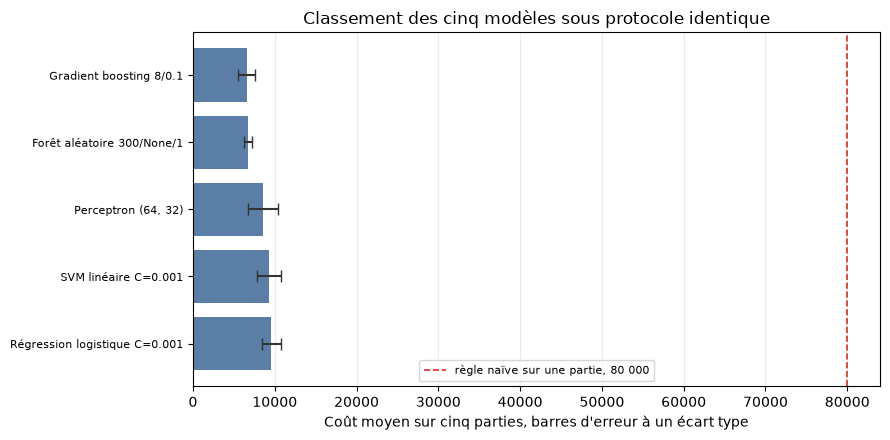

In [28]:
# Comparaison appariée : mêmes parties, mêmes camions
from scipy import stats

noms = [n for n in synthese.index if n != "témoin constant"]
ecarts = pd.DataFrame(np.nan, index=noms, columns=noms)
verdict = pd.DataFrame("", index=noms, columns=noms)

# Seuil de Student à 5 pour cent, quatre degrés de liberté
t_critique = stats.t.ppf(0.975, df=4)

for a in noms:
    for b in noms:
        if a == b:
            continue
        d = tableau[a]["cout"].values - tableau[b]["cout"].values
        erreur = d.std(ddof=1) / np.sqrt(len(d))
        ecarts.loc[a, b] = round(d.mean())
        verdict.loc[a, b] = "oui" if abs(d.mean()) > t_critique * erreur else "non"

print("Écart de coût moyen, ligne moins colonne :\n")
print(ecarts.to_string())
print("\n\nL'écart est-il significatif au sens du test apparié :\n")
print(verdict.to_string())

print("\n\nDétail des comparaisons deux à deux :\n")
for i, a in enumerate(noms):
    for b in noms[i + 1:]:
        d = tableau[a]["cout"].values - tableau[b]["cout"].values
        erreur = d.std(ddof=1) / np.sqrt(len(d))
        marque = "départageables" if abs(d.mean()) > t_critique * erreur else "non départageables"
        print(f"{a:<30} contre {b:<30} "
              f"{d.mean():>+8,.0f} ± {erreur:>6,.0f}   {marque}")

In [ ]:
print(f"{'modèle':<32} {'seuil brut':>12} {'dépondéré':>14}")
print("-" * 60)
for nom in noms:
    r = tableau[nom]
    print(f"{nom:<32} {r['seuil'].mean():>12.6f} "
          f"{r['seuil_depondere'].mean():>14.8f}")

In [29]:
# Quels modèles sont réellement départageables
seuil_departage = 2000
modeles = sans_temoin.sort_values("cout")

print(f"Seuil de départage fixé par le protocole : {seuil_departage:,} unités\n")
print("Groupes de modèles non départageables :\n")

groupe, groupes = [modeles.index[0]], []
for i in range(1, len(modeles)):
    if modeles["cout"].iloc[i] - modeles["cout"].iloc[i - 1] < seuil_departage:
        groupe.append(modeles.index[i])
    else:
        groupes.append(groupe)
        groupe = [modeles.index[i]]
groupes.append(groupe)

for rang, g in enumerate(groupes, start=1):
    couts = [f"{modeles.loc[m, 'cout']:,.0f}" for m in g]
    print(f"  rang {rang} : {', '.join(g)}")
    print(f"           coûts {', '.join(couts)}\n")

rapport = SEUIL_BAYES / s if s > 1e-9 else float("nan")
    print(f"{nom:<32} {s:>16.6f} {rapport:>18.2f}")


Seuil de départage fixé par le protocole : 2,000 unités

Groupes de modèles non départageables :

  rang 1 : Gradient boosting 8/0.1, Forêt aléatoire 300/None/1, Perceptron (64, 32), SVM linéaire C=0.001, Régression logistique C=0.001
           coûts 6,576, 6,714, 8,550, 9,326, 9,598



In [30]:
# Diagnostic de calibration des cinq modèles
print(f"{'modèle':<32} {'seuil dépondéré':>16} {'rapport au repère':>18}")
print("-" * 68)
for nom in modeles.index:
    s = modeles.loc[nom, "seuil_depondere"]
    print(f"{nom:<32} {s:>16.5f} {SEUIL_BAYES / s:>18.2f}")
print(f"\nRepère théorique : {SEUIL_BAYES:.5f}")
print("Un rapport proche de 1 indique un modèle bien calibré.")

modèle                            seuil dépondéré  rapport au repère
--------------------------------------------------------------------
Gradient boosting 8/0.1                   0.00000                inf
Forêt aléatoire 300/None/1                0.00070              28.01
Perceptron (64, 32)                       0.00780               2.51
SVM linéaire C=0.001                      0.00040              49.02
Régression logistique C=0.001             0.01450               1.35

Repère théorique : 0.01961
Un rapport proche de 1 indique un modèle bien calibré.


/tmp/ipykernel_21698/2808636166.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"{nom:<32} {s:>16.5f} {SEUIL_BAYES / s:>18.2f}")


### Conclusion du banc d'essai

Cinq modèles couvrant trois familles de biais inductifs ont été comparés sous
protocole strictement identique. Tous franchissent largement le repère de la
règle naïve, ce qui établit la valeur économique de l'approche.

Trois enseignements se dégagent.

Les modèles à base d'arbres devancent nettement les modèles linéaires, et le
perceptron multicouche se situe entre les deux. L'écart entre familles dépasse le
seuil de départage du protocole, ce qui autorise une conclusion sur les familles
et non sur les seules implémentations testées.

À l'intérieur de la famille dominante, les deux modèles ne sont pas
départageables sur le coût, leur écart étant très inférieur au seuil établi. Le
critère de départage disponible est alors la dispersion entre parties, qui
mesure la stabilité du résultat.

Le diagnostic de calibration donne un résultat contrasté selon les familles. Les
modèles linéaires produisent des seuils plus proches du repère théorique que les
modèles d'ensemble, dont la moyenne des votes tasse les probabilités. Ce constat
confirme le fondement de la décision D-11 : retenir le seuil théorique comme
point de fonctionnement aurait supposé une calibration qui n'est pas acquise.

Une réserve générale doit accompagner ces résultats. Le réglage des paramètres est
sommaire et de taille comparable pour les cinq modèles, conformément au périmètre
du projet. Le classement obtenu est donc celui de cinq modèles sommairement
réglés, et non celui de cinq modèles à leur meilleur.

Enfin, ces coûts sont mesurés sur des parties d'environ 9 600 lignes. Ils ne sont
pas directement comparables aux résultats publiés sur le jeu de test officiel,
qui en compte 16 000 avec un taux de pannes différent. Cette comparaison ne
deviendra possible qu'à l'ouverture du jeu de test.

In [1]:
# Le détail derrière un seul nombre de résumé
from sklearn.model_selection import StratifiedKFold
from src.config import GRAINE, N_PLIS

vc = StratifiedKFold(n_splits=N_PLIS, shuffle=True, random_state=GRAINE)
idx_app, idx_ev = next(iter(vc.split(X_app, y_app)))

modele = M.foret_aleatoire(300)
modele.fit(X_app.iloc[idx_app], y_app.iloc[idx_app])
proba = modele.predict_proba(X_app.iloc[idx_ev])[:, 1]

print(f"Camions évalués dans cette partie : {len(proba):,}")
print(f"Probabilités distinctes produites : {len(np.unique(proba)):,}")
print(f"\nLes vingt camions les plus à risque :")

detail = pd.DataFrame({
    "probabilite": proba,
    "verdict": np.where(proba >= 0.032, "A INSPECTER", "sain"),
    "realite": np.where(y_app.iloc[idx_ev] == 1, "panne APS", "autre panne"),
}, index=X_app.index[idx_ev]).sort_values("probabilite", ascending=False)

print(detail.head(20).to_string())
print(f"\nCes {len(proba):,} lignes se résument aux quatre comptes suivants :")
print(pd.crosstab(detail["verdict"], detail["realite"]).to_string())

ModuleNotFoundError: No module named 'src'